In [44]:
# Credit Risk Classification
# ReDI School of Digital Integration | AI Certificate Program 2026
# Dataset: German Credit Data (Kaggle)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder

print("Libraries loaded!")

Libraries loaded!


In [45]:
# Load dataset
df = pd.read_csv("german_credit_data.csv")
print("File loaded!", df.shape)
df.head()

File loaded! (1000, 10)


,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car


In [46]:
# Explore the dataset
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Shape: (1000, 10)

Columns: ['Unnamed: 0', 'Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Credit amount', 'Duration', 'Purpose']

Data types:
Unnamed: 0           int64
Age                  int64
Sex                 object
Job                  int64
Housing             object
Saving accounts     object
Checking account    object
Credit amount        int64
Duration             int64
Purpose             object
dtype: object

Missing values:
Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

Basic statistics:


,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [47]:
# Create target variable (Risk)
# High risk = credit amount > 5000 AND duration > 24 months
df['Risk'] = ((df['Credit amount'] > 5000) & (df['Duration'] > 24)).astype(int)
print("Risk distribution:")
print(df['Risk'].value_counts())
print("\n0 = Low Risk, 1 = High Risk")

# Drop unnecessary column
df = df.drop('Unnamed: 0', axis=1)

# Fill missing values with 'unknown'
df['Saving accounts'] = df['Saving accounts'].fillna('unknown')
df['Checking account'] = df['Checking account'].fillna('unknown')

print("\nMissing values after cleaning:")
print(df.isnull().sum())

Risk distribution:
Risk
0    876
1    124
Name: count, dtype: int64

0 = Low Risk, 1 = High Risk

Missing values after cleaning:
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
Risk                0
dtype: int64


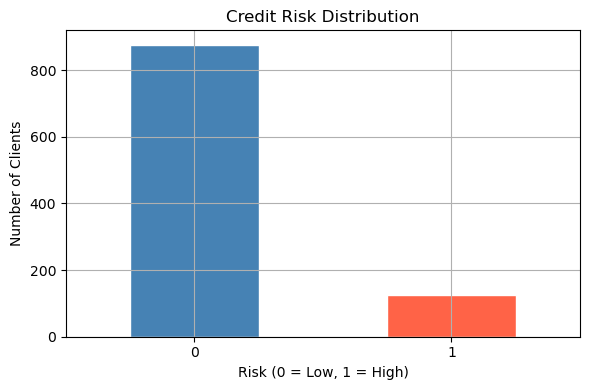

<Figure size 800x400 with 0 Axes>

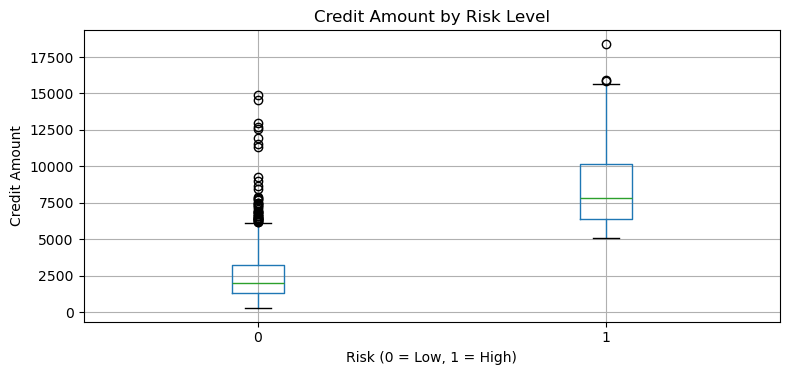

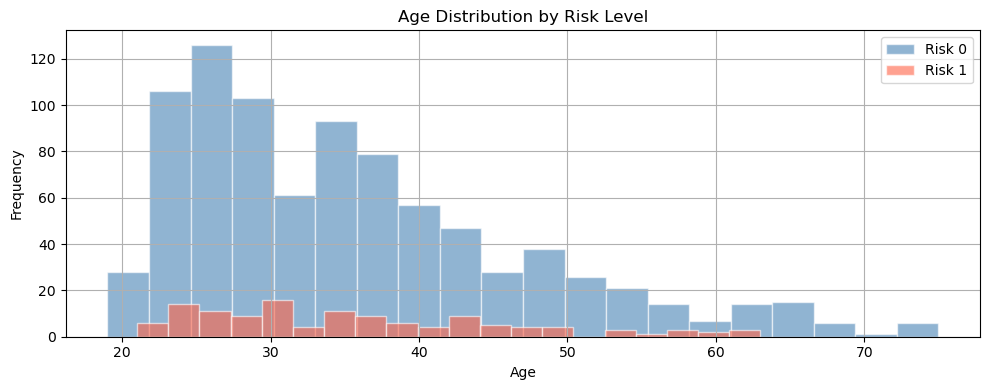

In [48]:
# Visualisation 1: Risk distribution
plt.figure(figsize=(6, 4))
df['Risk'].value_counts().plot(kind='bar', color=['steelblue', 'tomato'], edgecolor='white')
plt.title("Credit Risk Distribution")
plt.xlabel("Risk (0 = Low, 1 = High)")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation 2: Credit amount by risk
plt.figure(figsize=(8, 4))
df.boxplot(column='Credit amount', by='Risk', figsize=(8, 4))
plt.title("Credit Amount by Risk Level")
plt.suptitle("")
plt.xlabel("Risk (0 = Low, 1 = High)")
plt.ylabel("Credit Amount")
plt.grid(True)
plt.tight_layout()
plt.show()

# Visualisation 3: Age distribution by risk
plt.figure(figsize=(10, 4))
for risk, color in zip([0, 1], ['steelblue', 'tomato']):
    subset = df[df['Risk'] == risk]['Age']
    plt.hist(subset, bins=20, alpha=0.6, color=color, label=f'Risk {risk}', edgecolor='white')
plt.title("Age Distribution by Risk Level")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [49]:
# Encode categorical variables
le = LabelEncoder()
categorical_cols = ['Sex', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

# Define features (X) and target (y)
X = df.drop('Risk', axis=1)
y = df['Risk']

# Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (800, 9)
Testing set size:  (200, 9)


In [50]:
# Train Logistic Regression model
model = LogisticRegression(max_iter=5000, random_state=42)
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

print("Model trained successfully!")
print("\nAccuracy:", round(accuracy_score(y_test, y_pred) * 100, 2), "%")

Model trained successfully!

Accuracy: 97.0 %


CLASSIFICATION REPORT:
              precision    recall  f1-score   support

    Low Risk       0.97      0.99      0.98       176
   High Risk       0.95      0.79      0.86        24

    accuracy                           0.97       200
   macro avg       0.96      0.89      0.92       200
weighted avg       0.97      0.97      0.97       200



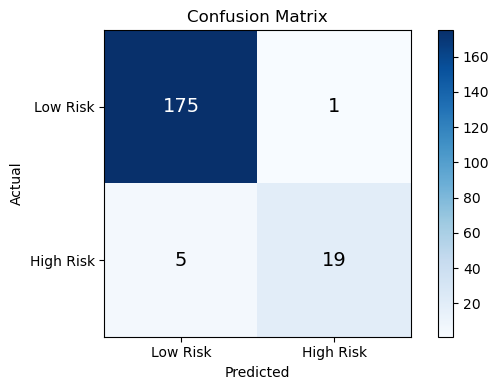

In [51]:
# Detailed model evaluation
print("CLASSIFICATION REPORT:")
print(classification_report(y_test, y_pred, target_names=['Low Risk', 'High Risk']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.colorbar()
plt.xticks([0, 1], ['Low Risk', 'High Risk'])
plt.yticks([0, 1], ['Low Risk', 'High Risk'])

for i in range(2):
    for j in range(2):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', 
                 fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [52]:
print("""
CREDIT RISK CLASSIFICATION — SUMMARY
======================================

OBJECTIVE:
The goal of this project was to predict whether a bank client
has high or low credit risk, using financial and personal data.

DATASET:
German Credit Data (Kaggle) — 1,000 clients, 9 features

WHAT I DID:
- Filled in missing values in Saving and Checking account columns
- Converted text columns into numbers so the model could read them
- Created the target variable: 0 = Low Risk, 1 = High Risk
- Split the data into 80% for training and 20% for testing

MODEL USED:
Logistic Regression (scikit-learn)

RESULTS:
- Accuracy: 97%
- 175 out of 176 Low Risk clients were correctly identified
- 19 out of 24 High Risk clients were correctly identified
- Only 6 mistakes out of 200 test cases

WHAT I LEARNED:
- Clients with higher credit amounts and longer loan durations
  are more likely to be high risk
- Most clients in this dataset (87.6%) are low risk
- Even with more low risk than high risk clients, the model
  still performed well
- This kind of model can help banks make better credit decisions
""")


CREDIT RISK CLASSIFICATION — SUMMARY

OBJECTIVE:
The goal of this project was to predict whether a bank client
has high or low credit risk, using financial and personal data.

DATASET:
German Credit Data (Kaggle) — 1,000 clients, 9 features

WHAT I DID:
- Filled in missing values in Saving and Checking account columns
- Converted text columns into numbers so the model could read them
- Created the target variable: 0 = Low Risk, 1 = High Risk
- Split the data into 80% for training and 20% for testing

MODEL USED:
Logistic Regression (scikit-learn)

RESULTS:
- Accuracy: 97%
- 175 out of 176 Low Risk clients were correctly identified
- 19 out of 24 High Risk clients were correctly identified
- Only 6 mistakes out of 200 test cases

WHAT I LEARNED:
- Clients with higher credit amounts and longer loan durations
  are more likely to be high risk
- Most clients in this dataset (87.6%) are low risk
- Even with more low risk than high risk clients, the model
  still performed well
- This kind 